# Wind Farm Layout Optimization
This notebook explains how FLOWERS can be used for Wind Farm Layout Optimization to maximize AEP. The simplest wake model, NO Jensen is used here, but the procedure is the same for all of FLOWERS models. 

FLOWERS has been seen to estimate a wind farm AEP with significant error, rendering it useless for this purpose. However, its integral formulation results in smooth design spaces, know for their suitability in gradient based optimizations.

The `topfarm` framework is used to run the optimization, using the wrapper for the gradient based algorithm SLSQP. This notebook shows its implementation for a 80 turbine rectangular wind farm.

Package imports

In [1]:
from FLOWERS.noj import NOJ_flowers
from py_wake.examples.data.hornsrev1 import Hornsrev1Site, V80
from topfarm.constraint_components.boundary import XYBoundaryConstraint
from topfarm.constraint_components.spacing import SpacingConstraint
from topfarm.cost_models.cost_model_wrappers import CostModelComponent
from py_wake.literature.noj import Jensen_1983
from topfarm import TopFarmProblem
from topfarm.easy_drivers import EasyScipyOptimizeDriver
import time
import matplotlib.pyplot as plt

# Ignore numerical errors coming from FLOWERS (division by zero, etc.)
import warnings
warnings.filterwarnings("ignore")

c:\Users\janbu\AppData\Local\anaconda3\envs\flowers\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Wind farm model

In [2]:
site = Hornsrev1Site()
turbine = V80()
x, y = site.initial_position.T

# Wake expansion coefficients
k_NOJ = 0.04

# Wind farm model
wfm_NOJ = NOJ_flowers(site = site,
                      windTurbines = turbine,
                      k = k_NOJ,
                      n_terms = 7)


# PyWake wind farm model to evaluate layouts
wfm = Jensen_1983(site=site, windTurbines=turbine, k=0.04)

Initial AEP using PyWake

In [3]:
initial_aep = wfm.aep(x, y)
print(f"Initial AEP: {initial_aep:.2f} GWh")

Initial AEP: 661.93 GWh


Build topfarm problem

In [4]:
# AEP function
def aep_func(x, y):
    return wfm_NOJ.aep(x, y)

# AEP gradients
def aep_gradient(x, y):
    return wfm_NOJ.aep_gradient(gradient_method="Autograd", wrt_arg=["x","y"], x=x, y=y)

# Setup constraints
min_dist = 5*turbine.diameter()
turb_sep_constraint = SpacingConstraint(min_dist)
boundary = [[x.min(), y.min()], [x.max(), y.min()], [x.max(), y.max()], [x.min(), y.max()], [x.min(), y.min()]]
boundary_constraint = XYBoundaryConstraint(boundary)

constraints = [turb_sep_constraint, boundary_constraint]

# Setup cost component
aep_comp = CostModelComponent(input_keys=[('x', x),('y', y)],
                              n_wt=len(x),
                              cost_function=aep_func,
                              cost_gradient_function=aep_gradient,
                              maximize=True,
                              objective=True,
                              output_keys=['AEP'])

# Set up driver
driver = EasyScipyOptimizeDriver(optimizer="SLSQP",
                                 maxiter=50,
                                 tol=10)

# Set up optimization problem
topfarm_problem = TopFarmProblem(design_vars=dict(zip(['x', 'y'], [x, y])),
                                 cost_comp=aep_comp,
                                 driver=driver,
                                 constraints=constraints,
                                 n_wt=len(x),
                                 expected_cost=1e-5)

Run the optimization

In [5]:
time_start = time.time()
print("Starting optimization...")
_, state, recorder = topfarm_problem.optimize()
time_end = time.time()

Starting optimization...
Iteration limit reached    (Exit mode 9)
            Current function value: -56573226.65529228
            Iterations: 50
            Function evaluations: 54
            Gradient evaluations: 51
Optimization FAILED.
Iteration limit reached
-----------------------------------


Results

Initial AEP from flow model: 661.93 GWh
Optimization completed in 11.61 seconds
Final AEP from flow model: 670.13


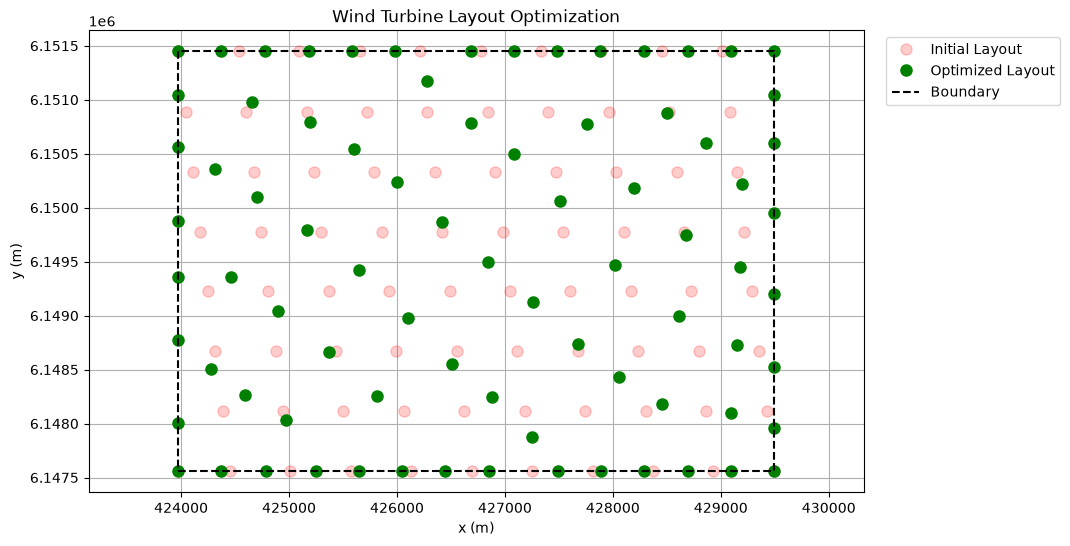

In [6]:
x_opt = state["x"]
y_opt = state["y"]

# Evaluate final layout using PyWake
sim_res = wfm(x_opt, y_opt,
            wd=site.default_wd,
            ws=site.default_ws)

final_aep = sim_res.aep().sum().values

print(f"Initial AEP from flow model: {initial_aep:.2f} GWh")
print(f"Optimization completed in {time_end - time_start:.2f} seconds")
print(f"Final AEP from flow model: {final_aep:.2f}")

plt.figure(figsize=(10, 6))
plt.plot(x, y, 'ro', label='Initial Layout', markersize=8, alpha=0.2)
plt.plot(x_opt, y_opt, 'go', label='Optimized Layout', markersize=8)
plt.plot([limit[0] for limit in boundary], [limit[1] for limit in boundary], 'k--', label='Boundary')
plt.axis('equal')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Wind Turbine Layout Optimization')
plt.legend(bbox_to_anchor=(1.02, 1))
plt.grid()